In [131]:
# Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [132]:
# Carga desde un archivo .csv sin indice
lr = pd.read_csv('Leads_reales.csv', header=[2]) 

In [133]:
# Verificamos información del DataFrame
lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   33 non-null     str    
 2   Total                 31 non-null     str    
 3   Ilocalizable          32 non-null     str    
 4   No Contesta           31 non-null     str    
 5   D. Incorrectos        31 non-null     str    
 6   Duplicados            33 non-null     str    
 7   Efectivos             30 non-null     str    
 8   Abiertos              32 non-null     str    
 9   Ventas                30 non-null     str    
 10  Conversion            34 non-null     str    
 11  Efectividad de Leads  30 non-null     str    
 12  Unnamed: 12           2 non-null      float64
 13  Unnamed: 13           0 non-null      float64
dtypes: float64(3), str(11)
memory usage: 4.9 KB


In [134]:
# Limpiamos la base
lr.columns = lr.columns.str.strip()
lr["Año"] = lr["Año"].ffill()
lr["Año"] = lr["Año"].astype(int)
lr = lr[:28]
lr = lr.drop(index=0)
lr = lr.drop(columns=["Unnamed: 12", "Unnamed: 13"])

In [135]:
# Cambiamos tipos de datos
cols = ["Total","Ilocalizable","No Contesta","D. Incorrectos","Duplicados","Efectivos","Abiertos","Ventas"]
lr[cols] = lr[cols].replace(",", "", regex=True).astype(int)

lr["Conversion"] = lr["Conversion"].str.rstrip("%").astype(float)
lr["Efectividad de Leads"] = lr["Efectividad de Leads"].str.rstrip("%").astype(float)

In [136]:
# Verificamos nuevamente la información del DataFrame
lr.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 1 to 27
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   27 non-null     int64  
 1   Mes                   27 non-null     str    
 2   Total                 27 non-null     int64  
 3   Ilocalizable          27 non-null     int64  
 4   No Contesta           27 non-null     int64  
 5   D. Incorrectos        27 non-null     int64  
 6   Duplicados            27 non-null     int64  
 7   Efectivos             27 non-null     int64  
 8   Abiertos              27 non-null     int64  
 9   Ventas                27 non-null     int64  
 10  Conversion            27 non-null     float64
 11  Efectividad de Leads  27 non-null     float64
dtypes: float64(2), int64(9), str(1)
memory usage: 2.7 KB


In [137]:
# Calculamos el numero total de la población "n"
lr['Efectivos'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Efectivos
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [138]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=lr['Efectivos'].max()
Min=lr['Efectivos'].min()
Limites= [Min, Max]
Limites

[np.int64(128), np.int64(1040)]

In [139]:
# Calculamos el rango R
R=Max-Min
R

np.int64(912)

In [140]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

np.float64(5.752127697007838)

In [141]:
# Calculamos el Ancho del Intervalo "i"
i=R/ni
i

np.float64(158.5500267100133)

In [142]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos=np.linspace(127.8, 1040.9, 6)
intervalos

array([ 127.8 ,  310.42,  493.04,  675.66,  858.28, 1040.9 ])

In [143]:
#Creamos las categorías 
categorias = ["Muy bajo (127.8-310.42)", "Bajo (310.42-493.04)", "Medio (493.04-675.66)",
              "Alto (675.66-858.28)", "Muy alto (858.28-1040.9)"]

In [144]:
# Finalmente creamos las categorías en la columna numérica
lr['Efectivos']=pd.cut(x= lr['Efectivos'], bins=intervalos, labels= categorias)
lr['Efectivos']

1         Bajo (310.42-493.04)
2      Muy bajo (127.8-310.42)
3      Muy bajo (127.8-310.42)
4      Muy bajo (127.8-310.42)
5        Medio (493.04-675.66)
6        Medio (493.04-675.66)
7        Medio (493.04-675.66)
8        Medio (493.04-675.66)
9         Alto (675.66-858.28)
10    Muy alto (858.28-1040.9)
11    Muy alto (858.28-1040.9)
12        Alto (675.66-858.28)
13        Bajo (310.42-493.04)
14        Alto (675.66-858.28)
15    Muy alto (858.28-1040.9)
16       Medio (493.04-675.66)
17        Alto (675.66-858.28)
18    Muy alto (858.28-1040.9)
19        Alto (675.66-858.28)
20       Medio (493.04-675.66)
21        Alto (675.66-858.28)
22        Alto (675.66-858.28)
23        Alto (675.66-858.28)
24        Alto (675.66-858.28)
25        Alto (675.66-858.28)
26    Muy alto (858.28-1040.9)
27        Alto (675.66-858.28)
Name: Efectivos, dtype: category
Categories (5, str): ['Muy bajo (127.8-310.42)' < 'Bajo (310.42-493.04)' < 'Medio (493.04-675.66)' < 'Alto (675.66-858.28)' < 'Muy

In [145]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq = lr['Efectivos'].value_counts().reset_index()
Tabla_freq

,Efectivos,count
0,Alto (675.66-858.28),11
1,Medio (493.04-675.66),6
2,Muy alto (858.28-1040.9),5
3,Muy bajo (127.8-310.42),3
4,Bajo (310.42-493.04),2


In [146]:
#Ajusto el indice de mi dataframe
Tabla_freq_i = Tabla_freq.set_index('Efectivos')
Tabla_freq_i

,count
Efectivos,
Alto (675.66-858.28),11
Medio (493.04-675.66),6
Muy alto (858.28-1040.9),5
Muy bajo (127.8-310.42),3
Bajo (310.42-493.04),2


Text(0, 0.5, 'Frecuencia')

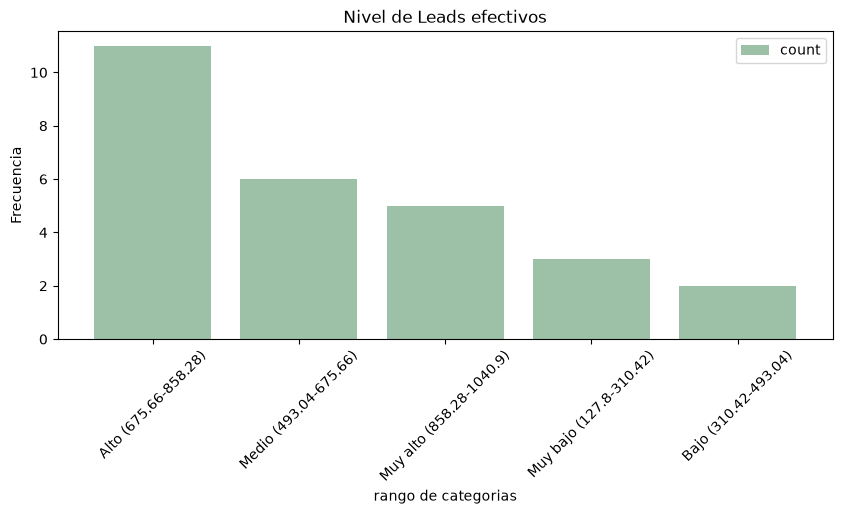

In [160]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "#9CC1A7", rot=45)
plt.title('Nivel de Leads efectivos')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [148]:
# Calculamos el numero total de la población "n"
lr['Abiertos'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Abiertos
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [149]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max1=lr['Abiertos'].max()
Min1=lr['Abiertos'].min()
Limites1= [Min1, Max1]
Limites1

[np.int64(1), np.int64(823)]

In [150]:
# Calculamos el rango R
R1=Max1-Min1
R1

np.int64(822)

In [151]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni1= 1+3.32*np.log10(n)
ni1

np.float64(5.752127697007838)

In [152]:
# Calculamos el Ancho del Intervalo "i"
i1=R1/ni1
i1

np.float64(142.90364249520937)

In [153]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos1=np.linspace(0.9, 823.9, 6)
intervalos1

array([  0.9, 165.5, 330.1, 494.7, 659.3, 823.9])

In [154]:
categorias_abiertos = ["Muy bajo (0.9-165.5)", "Bajo (165.5-330.1)", "Medio (330.1-494.7)", "Alto (494.7-659.3)", "Muy alto (659.3-823.9)"]

In [155]:
# Finalmente creamos las categorías en la columna numérica
lr['Abiertos']=pd.cut(x= lr['Abiertos'], bins=intervalos1, labels= categorias_abiertos)
lr['Abiertos']

1       Muy bajo (0.9-165.5)
2       Muy bajo (0.9-165.5)
3       Muy bajo (0.9-165.5)
4       Muy bajo (0.9-165.5)
5       Muy bajo (0.9-165.5)
6       Muy bajo (0.9-165.5)
7       Muy bajo (0.9-165.5)
8       Muy bajo (0.9-165.5)
9       Muy bajo (0.9-165.5)
10      Muy bajo (0.9-165.5)
11        Bajo (165.5-330.1)
12        Bajo (165.5-330.1)
13      Muy bajo (0.9-165.5)
14      Muy bajo (0.9-165.5)
15      Muy bajo (0.9-165.5)
16        Bajo (165.5-330.1)
17        Bajo (165.5-330.1)
18        Bajo (165.5-330.1)
19       Medio (330.1-494.7)
20        Bajo (165.5-330.1)
21        Bajo (165.5-330.1)
22       Medio (330.1-494.7)
23    Muy alto (659.3-823.9)
24        Alto (494.7-659.3)
25        Alto (494.7-659.3)
26    Muy alto (659.3-823.9)
27        Alto (494.7-659.3)
Name: Abiertos, dtype: category
Categories (5, str): ['Muy bajo (0.9-165.5)' < 'Bajo (165.5-330.1)' < 'Medio (330.1-494.7)' < 'Alto (494.7-659.3)' < 'Muy alto (659.3-823.9)']

In [156]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq1 = lr['Abiertos'].value_counts().reset_index()
Tabla_freq1

,Abiertos,count
0,Muy bajo (0.9-165.5),13
1,Bajo (165.5-330.1),7
2,Alto (494.7-659.3),3
3,Medio (330.1-494.7),2
4,Muy alto (659.3-823.9),2


In [157]:
#Ajusto el indice de mi dataframe
Tabla_freq_i1 = Tabla_freq1.set_index('Abiertos')
Tabla_freq_i1

,count
Abiertos,
Muy bajo (0.9-165.5),13
Bajo (165.5-330.1),7
Alto (494.7-659.3),3
Medio (330.1-494.7),2
Muy alto (659.3-823.9),2


Text(0, 0.5, 'Frecuencia')

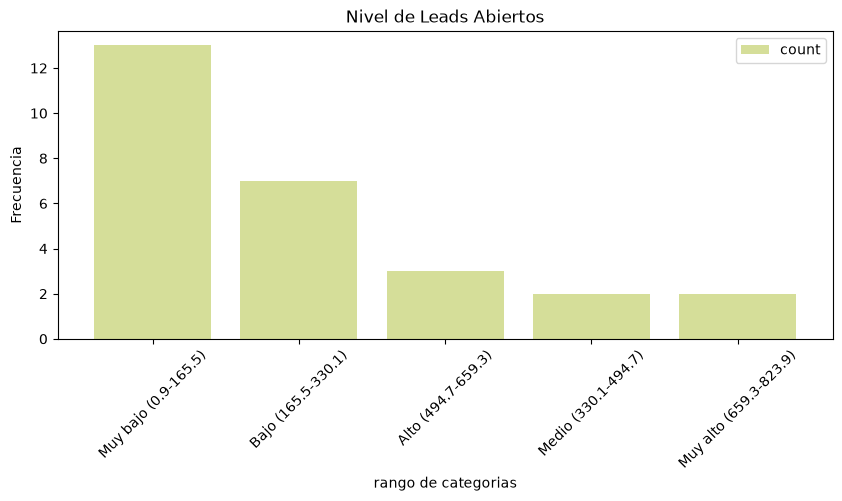

In [158]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i1.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "#D5DE99", rot=45)
plt.title('Nivel de Leads Abiertos')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

In [162]:
# Calculamos el numero total de la población "n"
lr['Ventas'].info()
n=27

<class 'pandas.Series'>
RangeIndex: 27 entries, 1 to 27
Series name: Ventas
Non-Null Count  Dtype
--------------  -----
27 non-null     int64
dtypes: int64(1)
memory usage: 348.0 bytes


In [163]:
# Obtenemos el limite superior y el límite inferior de la columna objetivo
Max2=lr['Ventas'].max()
Min2=lr['Ventas'].min()
Limites2= [Min2, Max2]
Limites2

[np.int64(6), np.int64(41)]

In [164]:
# Calculamos el rango R
R2=Max2-Min2
R2

np.int64(35)

In [165]:
# Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni2= 1+3.32*np.log10(n)
ni2

np.float64(5.752127697007838)

In [166]:
# Calculamos el Ancho del Intervalo "i"
i2=R2/ni2
i2

np.float64(6.084704972423756)

In [167]:
#Categorización de variables
#Declaramos 5 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
intervalos2=np.linspace(5.9, 41.9, 6)
intervalos2

array([ 5.9, 13.1, 20.3, 27.5, 34.7, 41.9])

In [168]:
categorias_ventas = ["Muy bajo (5.9-13.1)", "Bajo (13.1-20.3)", "Medio (20.3-27.5)", "Alto (27.5-34.7)", "Muy alto (34.7-41.9)"]

In [169]:
# Finalmente creamos las categorías en la columna numérica
lr['Ventas']=pd.cut(x= lr['Ventas'], bins=intervalos2, labels= categorias_ventas)
lr['Ventas']

1      Muy bajo (5.9-13.1)
2      Muy bajo (5.9-13.1)
3      Muy bajo (5.9-13.1)
4      Muy bajo (5.9-13.1)
5      Muy bajo (5.9-13.1)
6        Medio (20.3-27.5)
7         Bajo (13.1-20.3)
8         Bajo (13.1-20.3)
9        Medio (20.3-27.5)
10       Medio (20.3-27.5)
11        Alto (27.5-34.7)
12       Medio (20.3-27.5)
13        Bajo (13.1-20.3)
14        Alto (27.5-34.7)
15        Alto (27.5-34.7)
16        Alto (27.5-34.7)
17    Muy alto (34.7-41.9)
18    Muy alto (34.7-41.9)
19       Medio (20.3-27.5)
20    Muy alto (34.7-41.9)
21    Muy alto (34.7-41.9)
22    Muy alto (34.7-41.9)
23        Alto (27.5-34.7)
24    Muy alto (34.7-41.9)
25        Alto (27.5-34.7)
26    Muy alto (34.7-41.9)
27    Muy alto (34.7-41.9)
Name: Ventas, dtype: category
Categories (5, str): ['Muy bajo (5.9-13.1)' < 'Bajo (13.1-20.3)' < 'Medio (20.3-27.5)' < 'Alto (27.5-34.7)' < 'Muy alto (34.7-41.9)']

In [170]:
# Obtengo un análisis univariado de las variables categóricas
Tabla_freq2 = lr['Ventas'].value_counts().reset_index()
Tabla_freq2

,Ventas,count
0,Muy alto (34.7-41.9),8
1,Alto (27.5-34.7),6
2,Muy bajo (5.9-13.1),5
3,Medio (20.3-27.5),5
4,Bajo (13.1-20.3),3


In [171]:
#Ajusto el indice de mi dataframe
Tabla_freq_i2 = Tabla_freq2.set_index('Ventas')
Tabla_freq_i2

,count
Ventas,
Muy alto (34.7-41.9),8
Alto (27.5-34.7),6
Muy bajo (5.9-13.1),5
Medio (20.3-27.5),5
Bajo (13.1-20.3),3


Text(0, 0.5, 'Frecuencia')

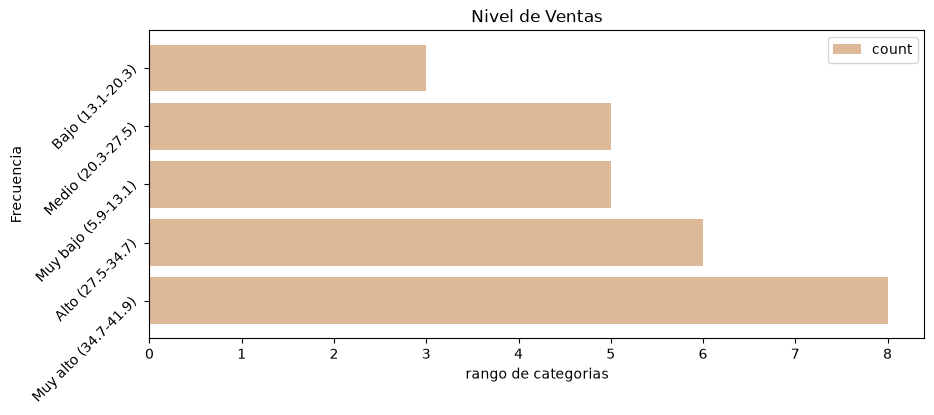

In [174]:
#Realizamos grafico de barras del dataframe filtrado
Tabla_freq_i2.plot(kind = 'barh', width=0.8, figsize=(10,4), color= "#DEB999", rot=45)
plt.title('Nivel de Ventas')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')